Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Downloaded rows: 2652

NBA Cup final being excluded:


,game_id,date,team,team_score
1876,401809839,2025-12-16,SA,113
1877,401809839,2025-12-16,NY,124



Games per team:


,team,games
0,ATL,82
1,BKN,82
2,BOS,82
3,CHA,82
4,CHI,82
5,CLE,82
6,DAL,82
7,DEN,82
8,DET,82
9,GS,82


Validated: 30 teams × 82 games.

MINNESOTA VS TOP 5 — 2025-26


,team,wins,losses,win_pct,ortg,drtg,net_rating,efg_pct,tov_pct,orb_pct
0,MIN,49,33,0.598,114.562,111.306,3.256,0.559,0.124,0.257
1,OKC,64,18,0.780,116.779,105.843,10.936,0.561,0.108,0.223
2,SA,62,20,0.756,117.436,109.297,8.139,0.559,0.112,0.262
3,DET,60,22,0.732,115.448,107.450,7.998,0.546,0.123,0.309
4,BOS,56,26,0.683,118.068,110.157,7.910,0.553,0.105,0.292
5,DEN,54,28,0.659,120.326,115.253,5.073,0.577,0.109,0.236


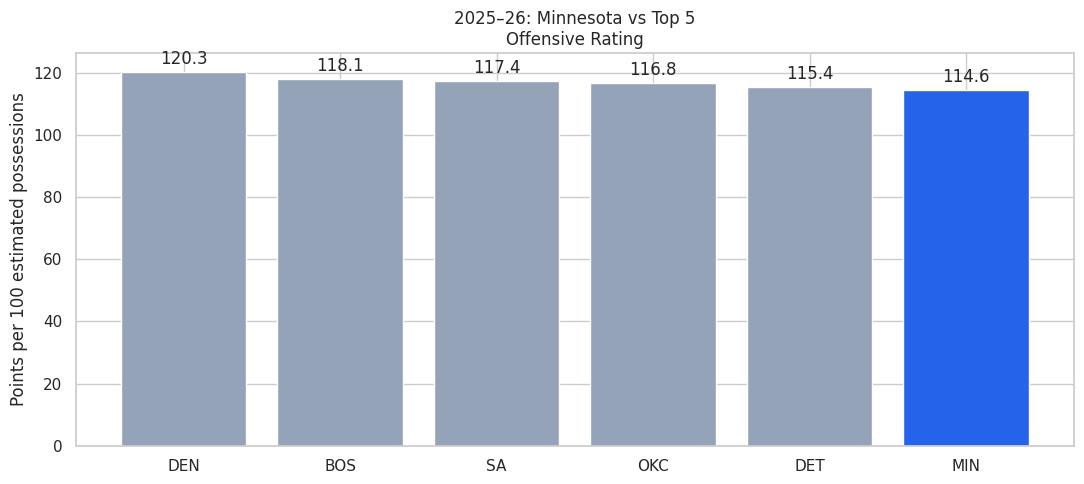

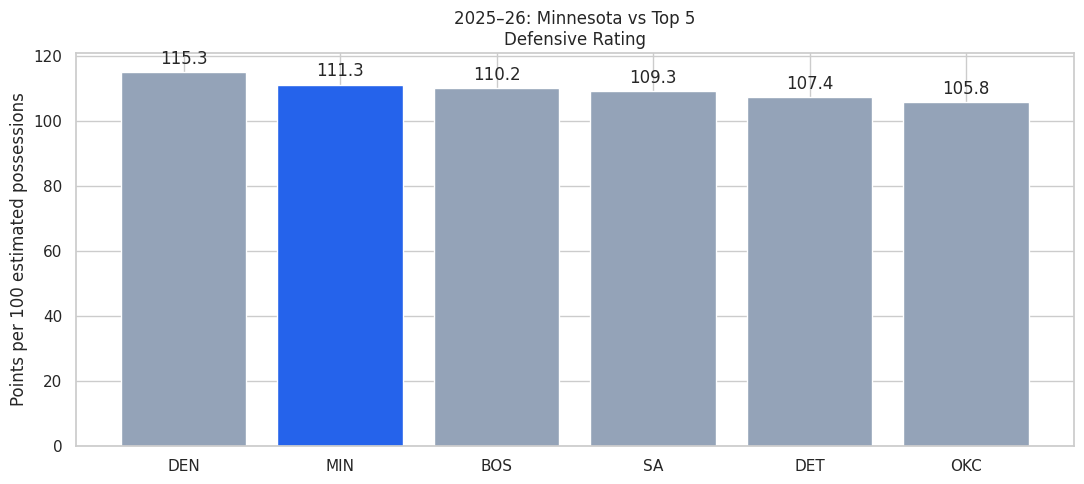

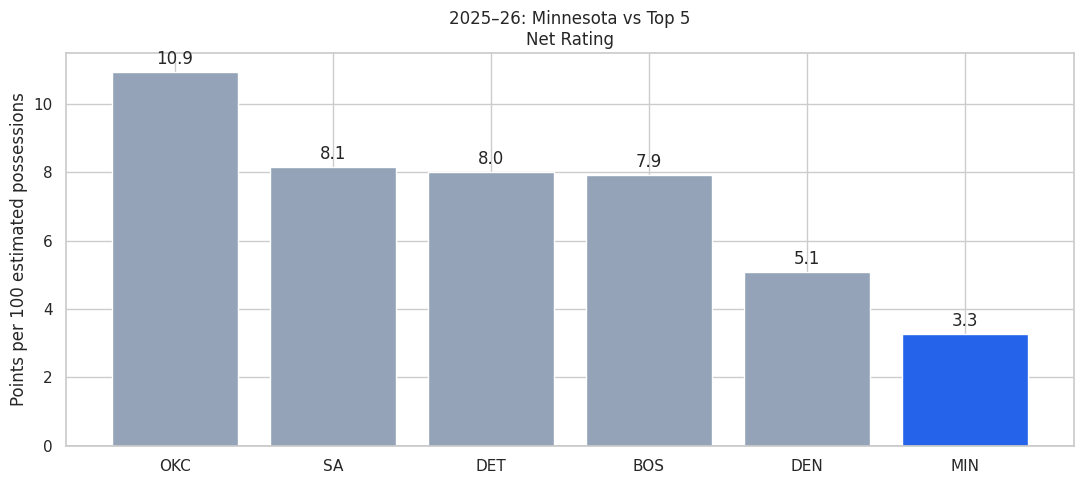

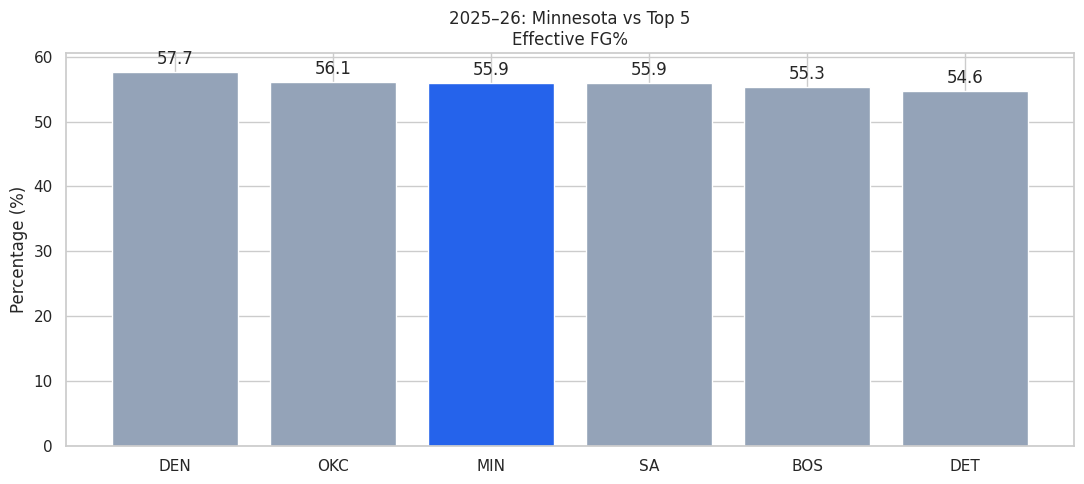

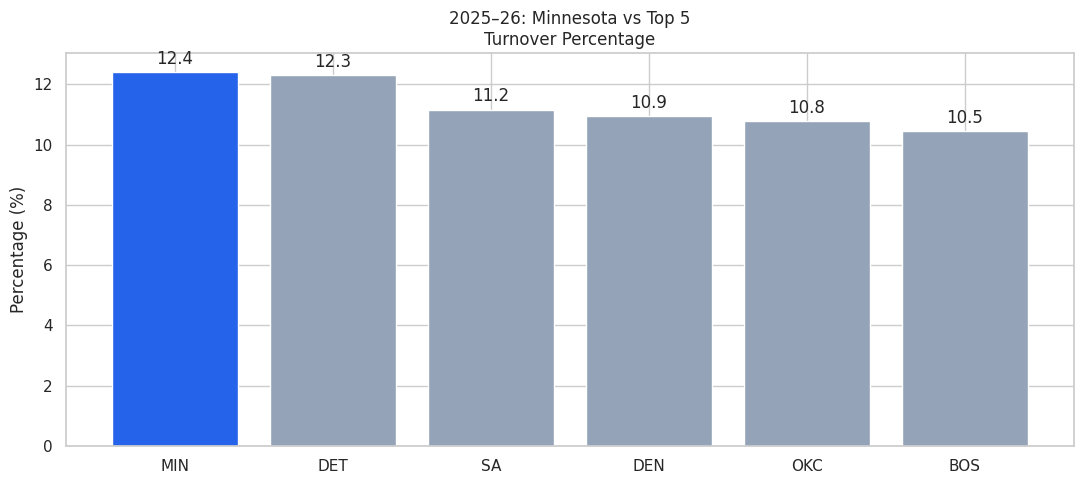

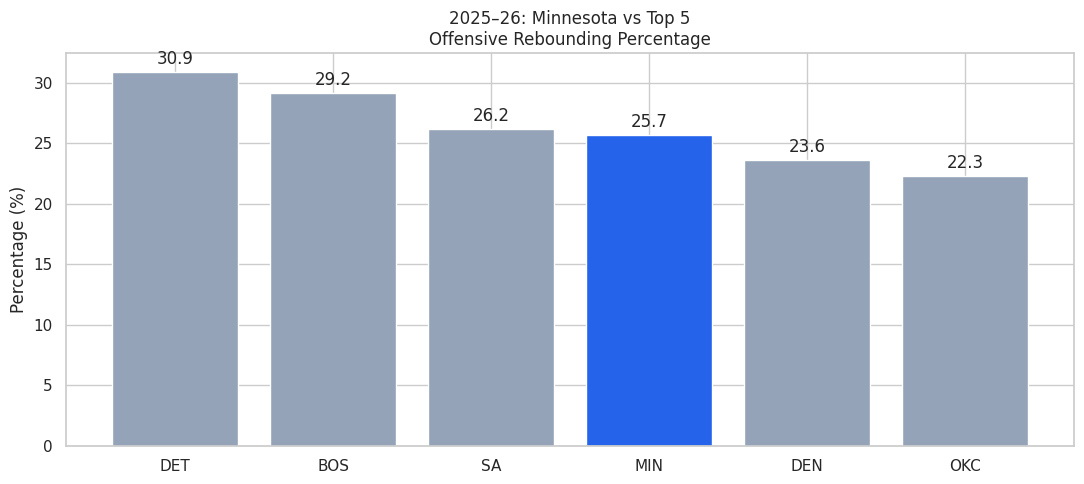


MINNESOTA VS TOP 5 AVERAGE


,metric,minnesota,top5_average,gap
0,Offensive Rating,114.56,117.61,-3.05
1,Defensive Rating,111.31,109.60,1.71
2,Net Rating,3.26,8.01,-4.76
3,Effective FG%,55.91,55.93,-0.02
4,Turnover Percentage,12.41,11.13,1.29
5,Offensive Rebounding Percentage,25.69,26.43,-0.74


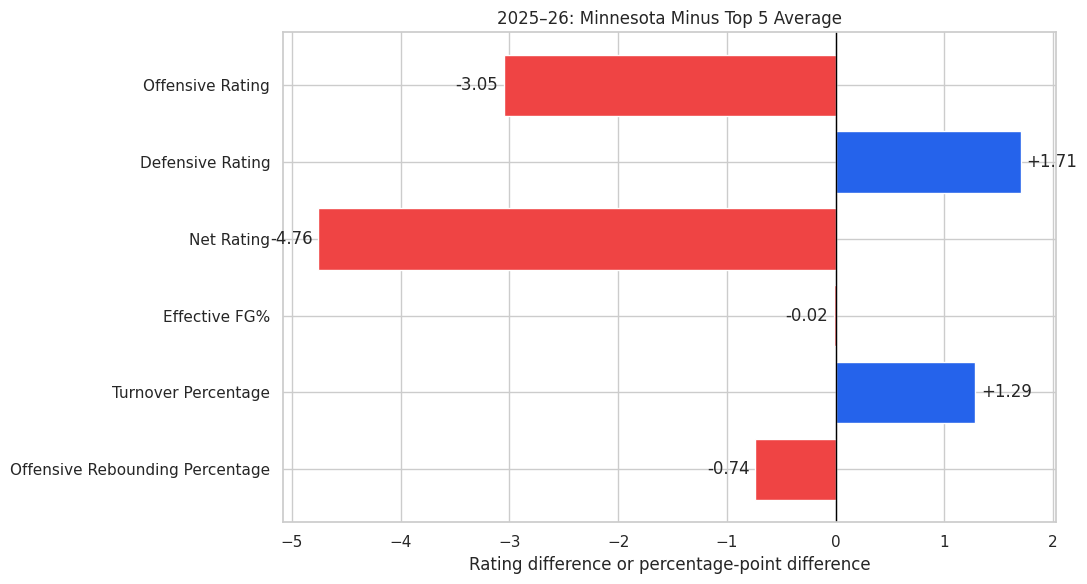


ANALYSIS COMPLETE
Data: /content/drive/MyDrive/minnesota_analysis/data/processed/top5_2026
Charts: /content/drive/MyDrive/minnesota_analysis/figures/top5_2026


In [ ]:

# ============================================================
# MINNESOTA VS TOP 5 — 2025-26 NBA REGULAR SEASON
# Complete Google Colab code
# ============================================================

%pip -q install pandas numpy pyarrow requests matplotlib seaborn

from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/minnesota_analysis")
RAW = ROOT / "data" / "raw"
OUT = ROOT / "data" / "processed" / "top5_2026"
FIG = ROOT / "figures" / "top5_2026"

for folder in [RAW, OUT, FIG]:
    folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. LOAD ONLY THE 2025-26 DATA
# ------------------------------------------------------------

YEAR = 2026
PATH = RAW / "team_box_2026.parquet"

URL = (
    "https://github.com/sportsdataverse/"
    "sportsdataverse-data/releases/download/"
    "espn_nba_team_boxscores/"
    "team_box_2026.parquet"
)

if not PATH.exists():
    print("Downloading 2025-26 team box scores...")

    with requests.get(URL, stream=True, timeout=120) as r:
        r.raise_for_status()

        with open(PATH, "wb") as f:
            for chunk in r.iter_content(1024 * 1024):
                if chunk:
                    f.write(chunk)

raw = pd.read_parquet(PATH)

print("Downloaded rows:", len(raw))

# ------------------------------------------------------------
# 2. REGULAR SEASON ONLY
# ------------------------------------------------------------

regular = raw[
    pd.to_numeric(
        raw["season_type"], errors="coerce"
    ) == 2
].copy()

regular["team"] = (
    regular["team_abbreviation"]
    .astype(str)
    .str.upper()
    .str.strip()
)

regular["game_id"] = (
    regular["game_id"].astype(str)
)

regular["date"] = pd.to_datetime(
    regular["game_date"],
    errors="coerce"
)

# Only the 30 NBA franchises.
NBA_TEAMS = {
    "ATL", "BOS", "BKN", "CHA", "CHI",
    "CLE", "DAL", "DEN", "DET", "GS",
    "HOU", "IND", "LAC", "LAL", "MEM",
    "MIA", "MIL", "MIN", "NO", "NY",
    "OKC", "ORL", "PHI", "PHX", "POR",
    "SAC", "SA", "TOR", "UTAH", "WSH"
}

regular = regular[
    regular["team"].isin(NBA_TEAMS)
].copy()

# ------------------------------------------------------------
# 3. EXCLUDE THE 2025 NBA CUP CHAMPIONSHIP
# ------------------------------------------------------------

# Knicks vs Spurs, December 16, 2025.
# This game does not count in regular-season standings.
# The December 31 NY-SA game remains included.

CUP_FINAL_ID = "401809839"

cup_rows = regular[
    regular["game_id"] == CUP_FINAL_ID
]

print("\nNBA Cup final being excluded:")
display(
    cup_rows[
        ["game_id", "date", "team", "team_score"]
    ]
)

if set(cup_rows["team"]) != {"NY", "SA"}:
    raise ValueError(
        "Cup-final ID did not match NY and SA. "
        "Check the downloaded dataset."
    )

regular = regular[
    regular["game_id"] != CUP_FINAL_ID
].copy()

# ------------------------------------------------------------
# 4. PREPARE THE BOX SCORES
# ------------------------------------------------------------

COLS = {
    "points": "team_score",
    "fgm": "field_goals_made",
    "fga": "field_goals_attempted",
    "three_pm": "three_point_field_goals_made",
    "fta": "free_throws_attempted",
    "orb": "offensive_rebounds",
    "drb": "defensive_rebounds",
    "tov": "turnovers"
}

for metric, source in COLS.items():
    regular[metric] = pd.to_numeric(
        regular[source],
        errors="coerce"
    )

STATS = list(COLS)

if regular[STATS].isna().any().any():
    print(regular[STATS].isna().sum())
    raise ValueError("Missing box-score statistics.")

if regular.duplicated(["game_id", "team"]).any():
    raise ValueError("Duplicate team-game rows.")

# ------------------------------------------------------------
# 5. VALIDATE ALL 82 GAMES
# ------------------------------------------------------------

coverage = (
    regular.groupby("team")["game_id"]
    .nunique()
    .sort_values()
)

print("\nGames per team:")
display(coverage.rename("games").reset_index())

if len(coverage) != 30 or not (coverage == 82).all():
    raise ValueError(
        "The 2025-26 dataset is incomplete or contains "
        "extra games. Inspect the coverage table."
    )

print("Validated: 30 teams × 82 games.")

# ------------------------------------------------------------
# 6. MATCH EACH TEAM WITH ITS OPPONENT
# ------------------------------------------------------------

team_games = regular[
    ["game_id", "date", "team"] + STATS
].copy()

opponent = regular[
    ["game_id", "team"] + STATS
].rename(
    columns={
        "team": "opponent",
        **{c: "opp_" + c for c in STATS}
    }
)

paired = team_games.merge(
    opponent,
    on="game_id",
    how="inner"
)

paired = paired[
    paired["team"] != paired["opponent"]
].copy()

if (
    len(paired) != 30 * 82
    or paired.duplicated(["game_id", "team"]).any()
):
    raise ValueError(
        "Opponent matching failed. "
        "Check the source game IDs."
    )

# ------------------------------------------------------------
# 7. ESTIMATED POSSESSIONS AND GAME RESULTS
# ------------------------------------------------------------

paired["team_poss"] = (
    paired["fga"]
    - paired["orb"]
    + paired["tov"]
    + 0.44 * paired["fta"]
)

paired["opp_poss"] = (
    paired["opp_fga"]
    - paired["opp_orb"]
    + paired["opp_tov"]
    + 0.44 * paired["opp_fta"]
)

paired["possessions"] = (
    paired["team_poss"] + paired["opp_poss"]
) / 2

if (paired["possessions"] <= 0).any():
    raise ValueError("Invalid possession estimates.")

paired["win"] = (
    paired["points"] > paired["opp_points"]
).astype(int)

paired["loss"] = (
    paired["points"] < paired["opp_points"]
).astype(int)

# ------------------------------------------------------------
# 8. CALCULATE SEASON STATISTICS
# ------------------------------------------------------------

stats = paired.groupby(
    "team", as_index=False
).agg(
    games=("game_id", "nunique"),
    wins=("win", "sum"),
    losses=("loss", "sum"),
    points=("points", "sum"),
    opp_points=("opp_points", "sum"),
    possessions=("possessions", "sum"),
    fgm=("fgm", "sum"),
    fga=("fga", "sum"),
    three_pm=("three_pm", "sum"),
    fta=("fta", "sum"),
    orb=("orb", "sum"),
    tov=("tov", "sum"),
    opp_drb=("opp_drb", "sum")
)

stats["win_pct"] = stats["wins"] / stats["games"]

stats["ortg"] = (
    100 * stats["points"] / stats["possessions"]
)

stats["drtg"] = (
    100 * stats["opp_points"] / stats["possessions"]
)

stats["net_rating"] = (
    stats["ortg"] - stats["drtg"]
)

stats["efg_pct"] = (
    stats["fgm"] + 0.5 * stats["three_pm"]
) / stats["fga"]

stats["tov_pct"] = stats["tov"] / (
    stats["fga"] + 0.44 * stats["fta"] + stats["tov"]
)

stats["orb_pct"] = (
    stats["orb"] /
    (stats["orb"] + stats["opp_drb"])
)

stats["point_diff_per_game"] = (
    stats["points"] - stats["opp_points"]
) / stats["games"]

stats.to_csv(
    OUT / "all_teams_2025_26.csv",
    index=False
)

# ------------------------------------------------------------
# 9. SELECT MINNESOTA + FIVE HIGHEST WIN%
# ------------------------------------------------------------

minnesota = stats[
    stats["team"] == "MIN"
].copy()

top5 = (
    stats[stats["team"] != "MIN"]
    .sort_values(
        ["win_pct", "net_rating"],
        ascending=False
    )
    .head(5)
    .copy()
)

minnesota["group"] = "Minnesota"
top5["group"] = "Top 5"

comparison = pd.concat(
    [minnesota, top5],
    ignore_index=True
)

print("\nMINNESOTA VS TOP 5 — 2025-26")
display(
    comparison[
        [
            "team", "wins", "losses",
            "win_pct", "ortg", "drtg",
            "net_rating", "efg_pct",
            "tov_pct", "orb_pct"
        ]
    ].round(3)
)

comparison.to_csv(
    OUT / "minnesota_vs_top5_2025_26.csv",
    index=False
)

# ------------------------------------------------------------
# 10. SIX INDIVIDUAL COMPARISON CHARTS
# ------------------------------------------------------------

METRICS = {
    "ortg": "Offensive Rating",
    "drtg": "Defensive Rating",
    "net_rating": "Net Rating",
    "efg_pct": "Effective FG%",
    "tov_pct": "Turnover Percentage",
    "orb_pct": "Offensive Rebounding Percentage"
}

PERCENT = {"efg_pct", "tov_pct", "orb_pct"}

for metric, label in METRICS.items():
    chart = comparison.copy()

    chart["value"] = chart[metric]

    if metric in PERCENT:
        chart["value"] *= 100

    chart = chart.sort_values(
        "value",
        ascending=False
    )

    colors = [
        "#2563eb" if t == "MIN" else "#94a3b8"
        for t in chart["team"]
    ]

    fig, ax = plt.subplots(figsize=(11, 5))

    bars = ax.bar(
        chart["team"],
        chart["value"],
        color=colors
    )

    ax.bar_label(bars, fmt="%.1f", padding=3)

    ax.set_title(
        f"2025–26: Minnesota vs Top 5\n{label}"
    )

    ax.set_ylabel(
        "Percentage (%)"
        if metric in PERCENT
        else "Points per 100 estimated possessions"
    )

    if metric == "net_rating":
        ax.axhline(0, color="black", linewidth=1)

    fig.tight_layout()

    fig.savefig(
        FIG / f"{metric}_comparison.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

# ------------------------------------------------------------
# 11. MINNESOTA VS TOP 5 AVERAGE
# ------------------------------------------------------------

top5_avg = top5[list(METRICS)].mean()

gap_rows = []

for metric, label in METRICS.items():
    min_value = float(minnesota.iloc[0][metric])
    avg_value = float(top5_avg[metric])

    multiplier = 100 if metric in PERCENT else 1

    gap_rows.append({
        "metric": label,
        "minnesota": min_value * multiplier,
        "top5_average": avg_value * multiplier,
        "gap": (min_value - avg_value) * multiplier
    })

gap = pd.DataFrame(gap_rows)

print("\nMINNESOTA VS TOP 5 AVERAGE")
display(gap.round(2))

gap.to_csv(
    OUT / "minnesota_top5_gap_2025_26.csv",
    index=False
)

# ------------------------------------------------------------
# 12. GAP CHART
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

colors = [
    "#2563eb" if x >= 0 else "#ef4444"
    for x in gap["gap"]
]

bars = ax.barh(
    gap["metric"],
    gap["gap"],
    color=colors
)

ax.axvline(0, color="black", linewidth=1)

ax.bar_label(
    bars,
    fmt="%+.2f",
    padding=4
)

ax.set_title(
    "2025–26: Minnesota Minus Top 5 Average"
)

ax.set_xlabel(
    "Rating difference or percentage-point difference"
)

ax.invert_yaxis()
fig.tight_layout()

fig.savefig(
    FIG / "minnesota_vs_top5_gap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

# ------------------------------------------------------------
# 13. SAVE MINNESOTA'S GAME-BY-GAME DATA
# ------------------------------------------------------------

min_games = paired[
    paired["team"] == "MIN"
].sort_values("date").copy()

min_games["game_number"] = range(
    1, len(min_games) + 1
)

min_games["ortg"] = (
    100 * min_games["points"]
    / min_games["possessions"]
)

min_games["drtg"] = (
    100 * min_games["opp_points"]
    / min_games["possessions"]
)

min_games["net_rating"] = (
    min_games["ortg"] - min_games["drtg"]
)

min_games.to_csv(
    OUT / "minnesota_game_by_game_2025_26.csv",
    index=False
)

print("\nANALYSIS COMPLETE")
print("Data:", OUT)
print("Charts:", FIG)